## Prepare various glyphs to be eventually used in the dataset

### **Star** – filled, with random color of the border and fill, and random border width

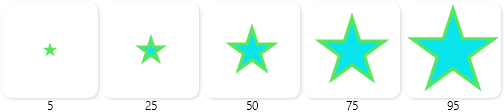

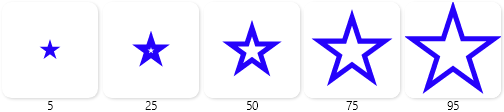

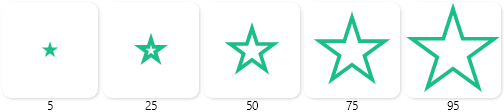

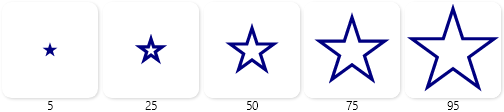

In [1]:
import mglyph as mg
import numpy as np
import random
from typing import Callable
import src.dataset_forming as df


def star(x: float, canvas: mg.Canvas, bordercolor, fillcolor, linewidth) -> None:
    canvas.tr.translate(0, mg.lerp(x, 0, 0.05))
    radius = mg.lerp(x, 0.01, canvas.ysize / 2)

    vertices = []
    for segment in range(5):
        vertices.append(mg.orbit(canvas.center, segment * 2 * np.pi / 5, radius))
        vertices.append(mg.orbit(canvas.center, (segment + 0.5) * 2 * np.pi / 5,
                         np.cos(2 * np.pi / 5) / np.cos(np.pi / 5) * radius))

    canvas.polygon(vertices, linecap='round', style='fill', color=fillcolor) 
    canvas.polygon(vertices, width=linewidth, linecap='round', style='stroke', color=bordercolor) 

def random_star() -> Callable[[float, mg.Canvas], None]:
    bordercolor = df.random_color()
    fillcolor = random.choice([df.random_color(), 'white'])
    linewidth = df.random_width(min=3, max=150)
    return lambda x, canvas: star(x, canvas, bordercolor, fillcolor, linewidth)
def simple_star() -> Callable[[float, mg.Canvas], None]:
    bordercolor = 'navy'
    fillcolor = 'white'
    linewidth = '70p'  
    return lambda x, canvas: star(x, canvas, bordercolor, fillcolor, linewidth)


for _ in range(3):
    mg.show(random_star())
mg.show(simple_star())

### Random **textual character**

This <mark>can be improved</mark> by also randomly selecting the font name, weight, slant, etc.

In [ ]:
def scaled_letter(x: float, canvas: mg.Canvas, color, character) -> None:
    canvas.text(character, (0,0), 'Arial', mg.lerp(x, 0.05, 2.0), 
                anchor='center', color=color, font_weight='bold', font_slant='upright')

def random_letter() -> Callable[[float, mg.Canvas], None]:
    color = tuple(random.random() for _ in range(3))
    character = random.choice('abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZěščřžýáíéóúťďňĚŠČŘŽÝÁÍÉÓÚŤĎŇ0123456789')
    return lambda x, canvas: scaled_letter(x, canvas, color, character)

for _ in range(3):
    mg.show(random_letter())

Now Square, circle and letter B

In [ ]:
import mglyph as mg
import numpy as np
import random
from typing import Callable
import src.dataset_forming as df


# === Drawer for scaled square ===
def simple_scaled_square(x: float, canvas: mg.Canvas) -> None:
    tl = (mg.lerp(x, 0.0, -1), mg.lerp(x, 0.0, -1.0))
    br = (mg.lerp(x, 0, 1), mg.lerp(x, 0, 1))
    canvas.rect(tl, br, color='red', style='stroke', width='60p')


def simple_square() -> Callable[[float, mg.Canvas], None]:
    return lambda x, canvas: simple_scaled_square(x, canvas)


# === Drawer for scaled circle ===
def simple_scaled_circle(x: float, canvas: mg.Canvas) -> None:
    canvas.circle(canvas.center, mg.lerp(x, 0.01, canvas.ysize/2),
                  color='green', style='stroke', width='70p')


def simple_circle() -> Callable[[float, mg.Canvas], None]:
    return lambda x, canvas: simple_scaled_circle(x, canvas)


# === Drawer for scaled letter ===
def scaled_letter(x: float, canvas: mg.Canvas, color, character) -> None:
    canvas.text(character, (0, 0), 'Arial', mg.lerp(x, 0.05, 2.0),
                anchor='center', color=color, font_weight='bold', font_slant='upright')


def b_letter() -> Callable[[float, mg.Canvas], None]:
    color = "orange"
    character = random.choice('B')
    return lambda x, canvas: scaled_letter(x, canvas, color, character)


# === Usage (for testing/preview) ===
mg.show(b_letter())
mg.show(simple_square())
mg.show(simple_circle())


## Now Make a Dataset

### First just random stars – `data/stars-small.zip` and `data/stars-large.zip`

In [3]:
import src.dataset_forming as df

# # Stars - small version
# with df.GlyphExporter(filepath='data/stars-small.zip', dataset_name="Stars (small)") as exporter:
#     shit_to_disappear = {"version": "1.0.0", 'name': ""}
#     for _ in range(10):
#         exporter.add(mg.export(random_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 10)), split='train')
#         exporter.add(mg.export(random_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 2)), split='test')

# # # Stars - large version
# with df.GlyphExporter(filepath='data/stars-large.zip', dataset_name="Stars (large)") as exporter:
#     shit_to_disappear = {"version": "1.0.0", 'name': ""}
#     for _ in range(100):
#         exporter.add(mg.export(random_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 100)), split='train')
#         exporter.add(mg.export(random_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 20)), split='test')

# # Simple Star   
# with df.GlyphExporter(filepath='data/simple-star.zip', dataset_name="Star (simple)") as exporter:
#     shit_to_disappear = {"version": "1.0.0", 'name': ""}
#     for _ in range(10):
#         exporter.add(mg.export(simple_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 50)), split='train')
#         exporter.add(mg.export(simple_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 10)), split='test')
        
# with df.GlyphExporter(filepath='data/simple-star-L.zip', dataset_name="Star (simple)") as exporter:
#     shit_to_disappear = {"version": "1.0.0", 'name': ""}
#     for _ in range(200):
#         exporter.add(mg.export(simple_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 50)), split='train')
#         exporter.add(mg.export(simple_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 10)), split='test')
        
# 5xbigger Simple Star   
with df.GlyphExporter(filepath='data/simple-star-L.zip', dataset_name="Star (simple)") as exporter:
    shit_to_disappear = {"version": "1.0.0", 'name': ""}
    for _ in range(50):
        exporter.add(mg.export(simple_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
                               xvalues=np.random.uniform(0.0, 100.0, 50)), split='train')
        exporter.add(mg.export(simple_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
                               xvalues=np.random.uniform(0.0, 100.0, 10)), split='test')

# # Simple Star-XL
# with df.GlyphExporter(filepath='data/simple-star-L.zip', dataset_name="Star (simple)") as exporter:
#     shit_to_disappear = {"version": "1.0.0", 'name': ""}
#     for _ in range(200):
#         exporter.add(mg.export(simple_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 50)), split='train')
#         exporter.add(mg.export(simple_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 10)), split='test')
        
# #Random Stars - XL version
# with df.GlyphExporter(filepath='data/random-stars-L.zip', dataset_name="Stars (large)") as exporter:
#     shit_to_disappear = {"version": "1.0.0", 'name': ""}
#     for _ in range(200):
#         exporter.add(mg.export(random_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 50)), split='train')
#         exporter.add(mg.export(random_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 10)), split='test')

# Simple stars test

with df.GlyphExporter(filepath='data/simple-star-test.zip', dataset_name="Star (simple)") as exporter:
    shit_to_disappear = {"version": "1.0.0", 'name': ""}
    for _ in range(50):
        exporter.add(mg.export(simple_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
                               xvalues=np.random.uniform(0.0, 100.0, 10)), split='test')
        
# # Simple B letter   
# with df.GlyphExporter(filepath='data/simple-Bletter.zip', dataset_name="B letter (simple)") as exporter:
#     shit_to_disappear = {"version": "1.0.0", 'name': ""}
#     for _ in range(10):
#         exporter.add(mg.export(b_letter(), path=None, short_name="letter", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 50)), split='train')
#         exporter.add(mg.export(b_letter(), path=None, short_name="letter", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 10)), split='test')
        
# #simple_scaled_square  
# with df.GlyphExporter(filepath='data/simple-square.zip', dataset_name="square (simple)") as exporter:
#     shit_to_disappear = {"version": "1.0.0", 'name': ""}
#     for _ in range(10):
#         exporter.add(mg.export(simple_square(), path=None, short_name="square", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 50)), split='train')
#         exporter.add(mg.export(simple_square(), path=None, short_name="square", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 10)), split='test')
        
# # simple_scaled_circle   
# with df.GlyphExporter(filepath='data/simple-circle.zip', dataset_name="circle (simple)") as exporter:
#     shit_to_disappear = {"version": "1.0.0", 'name': ""}
#     for _ in range(10):
#         exporter.add(mg.export(simple_circle(), path=None, short_name="circle", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 50)), split='train')
#         exporter.add(mg.export(simple_circle(), path=None, short_name="circle", silent=True, **shit_to_disappear,
#                                xvalues=np.random.uniform(0.0, 100.0, 10)), split='test')

### Then a mixture of stars and letters `data/stars-and-letters.zip`

In [ ]:
import src.dataset_forming as df

with df.GlyphExporter(filepath='data/stars-and-letters.zip', dataset_name="Stars and Letters") as exporter:
    shit_to_disappear = {"version": "1.0.0", 'name': ""}
    for _ in range(10):
        exporter.add(mg.export(random_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
                               xvalues=np.linspace(0.0, 100.0, 10)),split='train')
        exporter.add(mg.export(random_letter(), path=None, short_name="letter", silent=True, **shit_to_disappear,
                               xvalues=np.linspace(0.0, 100.0, 10)),split='train') 
        exporter.add(mg.export(random_star(), path=None, short_name="star", silent=True, **shit_to_disappear,
                               xvalues=np.linspace(0.0, 100.0, 2)),split='test')
        exporter.add(mg.export(random_letter(), path=None, short_name="letter", silent=True, **shit_to_disappear,
                               xvalues=np.linspace(0.0, 100.0, 2)),split='test') 
        

## Display Dataset

In [ ]:
import src.dataset_forming as df

df.display_dataset('data/simple-star.zip')